In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


I0000 00:00:1780410280.936666    9069 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780410281.406505    9069 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780410283.174921    9069 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
 
img_path = "../data/images/animales.jpg"
 
img = image.load_img(img_path, target_size=(224, 224), color_mode="grayscale")

# Convert image to numpy array
img_array = image.img_to_array(img)
# Normalize pixel values
img_array = img_array / 255.0





# # img_array shape: (224, 224, 1)
# img_2d = np.squeeze(img_array)   # shape becomes (224, 224)

# print(img_2d.shape)

# fig, ax = plt.subplots(figsize=(80, 80))  # big figure for zooming

# # Show grayscale image
# ax.imshow(img_2d, cmap="gray")

# # Create 224 x 224 grid
# ax.set_xticks(np.arange(-0.5, 224, 1), minor=True)
# ax.set_yticks(np.arange(-0.5, 224, 1), minor=True)

# ax.grid(which="minor", linewidth=0.2)

# # Remove normal axis labels
# ax.set_xticks([])
# ax.set_yticks([])

# # Write value inside every box
# for i in range(224):
#     for j in range(224):
#         value = img_2d[i, j]

#         ax.text(
#             j, i,
#             f"{value:.2f}",   # use .0f if values are 0-255
#             ha="center",
#             va="center",
#             fontsize=2
#         )

# plt.tight_layout()

# # Save as high-resolution image
# plt.savefig("pixel_grid_224x224.png", dpi=300, bbox_inches="tight")

# plt.show()



(224, 224)


In [15]:
un_array =np.array([
    
    [
        [1],[1],[1]
    ],
    [
        [1],[1],[1]
    ]
    ])
print(np.squeeze(un_array)[0][0])

1


In [ ]:

# Conv2D input shape should be: batch, height, width, channel
input_img = np.expand_dims(img_array, axis=0)

# Create Conv2D layer with 3 filters
conv_layer = tf.keras.layers.Conv2D(
    filters=3,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False
)

# Build layer
conv_layer(input_img)

# Define filters manually
vertical_edge = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

horizontal_edge = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

outline = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
], dtype=np.float32)

# Conv2D kernel shape:
# height, width, input_channel, number_of_filters
kernel = np.zeros((3, 3, 1, 3), dtype=np.float32)

kernel[:, :, 0, 0] = vertical_edge
kernel[:, :, 0, 1] = horizontal_edge
kernel[:, :, 0, 2] = outline

# Set filters into Conv2D layer
conv_layer.set_weights([kernel])

# Apply Conv2D
output = conv_layer(input_img)

# Convert tensor to numpy
output = output.numpy()[0]

# Plot everything
plt.figure(figsize=(14, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_array.squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(output[:, :, 0], cmap="gray")
plt.title("Vertical Edge")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(output[:, :, 1], cmap="gray")
plt.title("Horizontal Edge")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(output[:, :, 2], cmap="gray")
plt.title("Outline")
plt.axis("off")

plt.show()

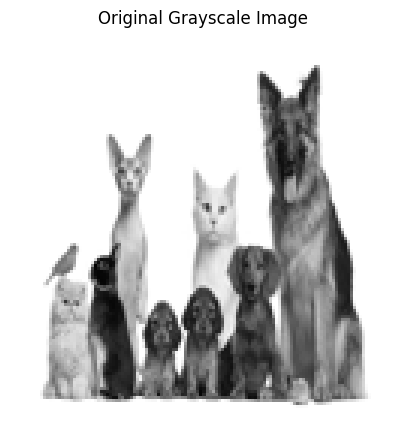

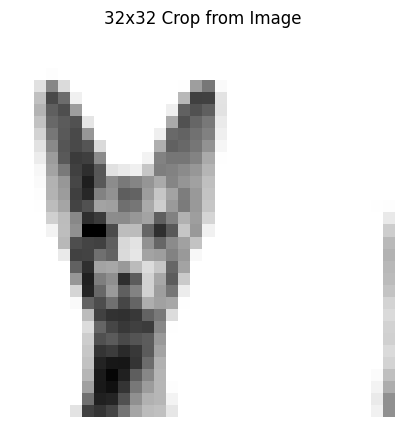

Total number of 3x3 patches: 900


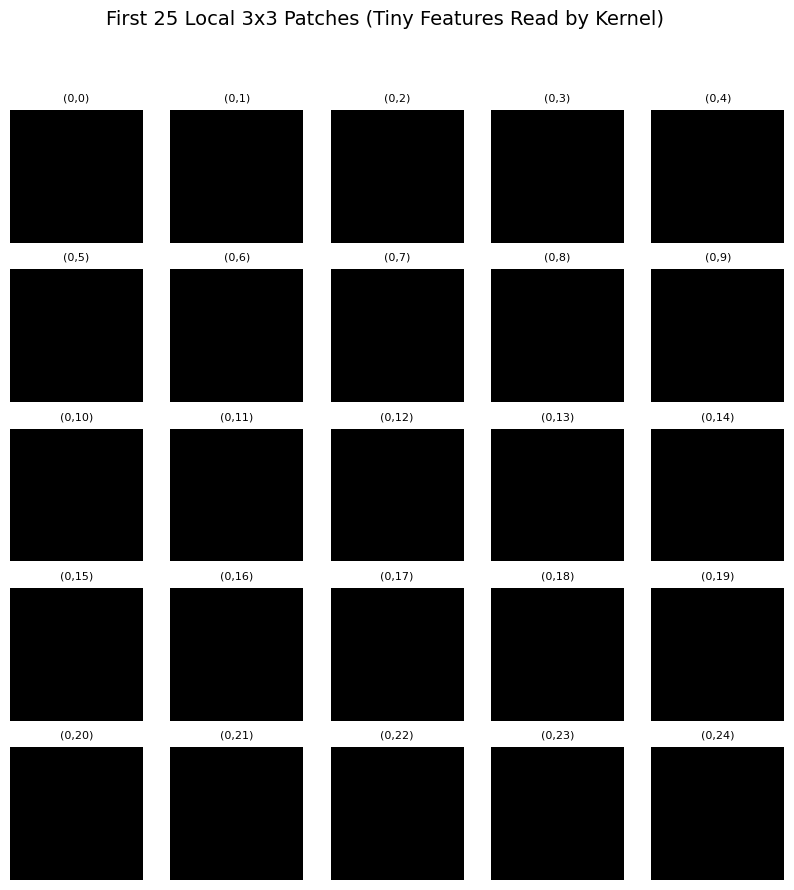

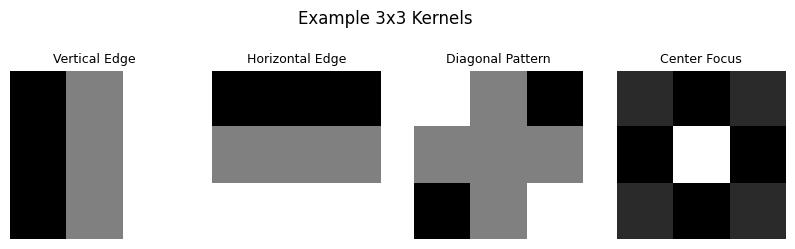

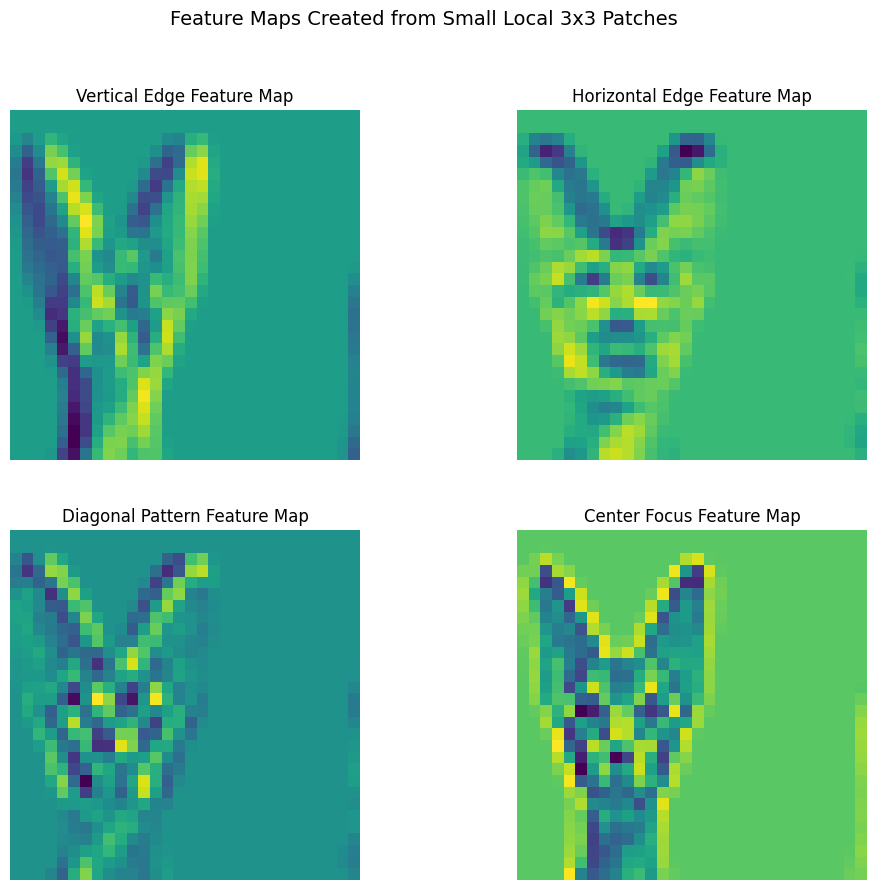

Sample patch position: (3, 10)
Sample patch:
 [[255. 255. 255.]
 [255. 255. 255.]
 [255. 255. 255.]]
Kernel used:
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
Output value from this one patch: 0.0


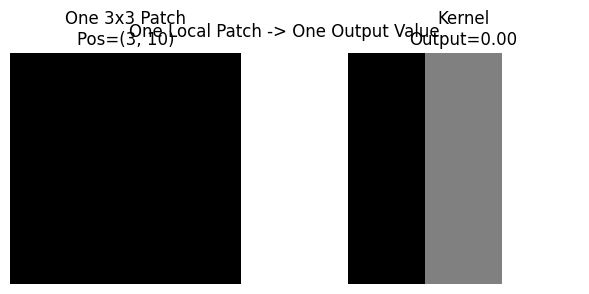

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# =========================================
# 1. Put your image URL here
# =========================================
IMG_URL = "../data/images/animals.jpg"


# =========================================
# 2. Load image and convert to grayscale
# =========================================
def load_grayscale_image(url, resize=(128, 128)):
    # response = requests.get(url)
    # img = Image.open(BytesIO(response.content)).convert("L")  # grayscale
    img = Image.open(url).convert("L")  # grayscale
    img = img.resize(resize)
    return np.array(img, dtype=np.float32)

img = load_grayscale_image(IMG_URL, resize=(128, 128))

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


# =========================================
# 3. Take a smaller crop for easy learning
# =========================================
crop = img[30:62, 30:62]   # 32x32 crop

plt.figure(figsize=(5, 5))
plt.imshow(crop, cmap="gray")
plt.title("32x32 Crop from Image")
plt.axis("off")
plt.show()


# =========================================
# 4. Extract sliding 3x3 patches manually
# =========================================
def extract_patches(image, kernel_size=3, stride=1):
    h, w = image.shape
    patches = []
    positions = []

    for i in range(0, h - kernel_size + 1, stride):
        for j in range(0, w - kernel_size + 1, stride):
            patch = image[i:i+kernel_size, j:j+kernel_size]
            patches.append(patch)
            positions.append((i, j))

    return patches, positions

patches, positions = extract_patches(crop, kernel_size=3, stride=1)

print("Total number of 3x3 patches:", len(patches))


# =========================================
# 5. Show first 25 tiny 3x3 patches
# =========================================
plt.figure(figsize=(10, 10))
for idx in range(25):
    plt.subplot(5, 5, idx + 1)
    plt.imshow(patches[idx], cmap="gray")
    i, j = positions[idx]
    plt.title(f"({i},{j})", fontsize=8)
    plt.axis("off")

plt.suptitle("First 25 Local 3x3 Patches (Tiny Features Read by Kernel)", fontsize=14)
plt.show()


# =========================================
# 6. Manual convolution
# =========================================
def manual_conv2d(image, kernel, stride=1):
    kh, kw = kernel.shape
    h, w = image.shape

    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for i in range(0, h - kh + 1, stride):
        for j in range(0, w - kw + 1, stride):
            patch = image[i:i+kh, j:j+kw]
            output[i // stride, j // stride] = np.sum(patch * kernel)

    return output


# =========================================
# 7. Some example kernels
# =========================================
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

horizontal_edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

diagonal_kernel = np.array([
    [ 1,  0, -1],
    [ 0,  0,  0],
    [-1,  0,  1]
], dtype=np.float32)

center_focus_kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)

kernels = {
    "Vertical Edge": vertical_edge_kernel,
    "Horizontal Edge": horizontal_edge_kernel,
    "Diagonal Pattern": diagonal_kernel,
    "Center Focus": center_focus_kernel
}


# =========================================
# 8. Show kernels
# =========================================
plt.figure(figsize=(10, 3))
for idx, (name, kernel) in enumerate(kernels.items()):
    plt.subplot(1, 4, idx + 1)
    plt.imshow(kernel, cmap="gray")
    plt.title(name, fontsize=9)
    plt.axis("off")
plt.suptitle("Example 3x3 Kernels")
plt.show()


# =========================================
# 9. Apply kernels to crop -> feature maps
# =========================================
feature_maps = {}

for name, kernel in kernels.items():
    fmap = manual_conv2d(crop, kernel)
    feature_maps[name] = fmap

plt.figure(figsize=(12, 10))
for idx, (name, fmap) in enumerate(feature_maps.items()):
    plt.subplot(2, 2, idx + 1)
    plt.imshow(fmap, cmap="viridis")
    plt.title(f"{name} Feature Map")
    plt.axis("off")
plt.suptitle("Feature Maps Created from Small Local 3x3 Patches", fontsize=14)
plt.show()


# =========================================
# 10. Show how one patch creates one output value
# =========================================
sample_index = 100   # choose any patch index
sample_patch = patches[sample_index]
sample_pos = positions[sample_index]

kernel = vertical_edge_kernel
sample_value = np.sum(sample_patch * kernel)

print("Sample patch position:", sample_pos)
print("Sample patch:\n", sample_patch)
print("Kernel used:\n", kernel)
print("Output value from this one patch:", sample_value)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(sample_patch, cmap="gray")
plt.title(f"One 3x3 Patch\nPos={sample_pos}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(kernel, cmap="gray")
plt.title(f"Kernel\nOutput={sample_value:.2f}")
plt.axis("off")

plt.suptitle("One Local Patch -> One Output Value")
plt.show()